In [4]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt

## Problem statement

The goal of this lab is to perform classification, using logistic regression, on simple self-generated data.

We'll create the data using sklearn's make_blobs.

[[-7.80035095 -7.04270464  5.96328448]
 [-4.04845159 -7.29381183  5.13241409]
 [-2.48535815 -7.54721806  4.97074164]
 ...
 [-3.05032695 -6.34546815  6.98921701]
 [-5.71351544 -5.74668089  6.73178426]
 [-1.98271335 -5.78692748  5.84049714]]
[0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0 0
 1 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0
 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 1 1 1 0 1 1 0 1 0 0
 1 1 1 1 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0
 0 0 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 1
 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 0
 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 1 0 0 0 1 1 1
 0 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0 1
 0 1 1 1 1 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1 0
 0 0 1 1 1

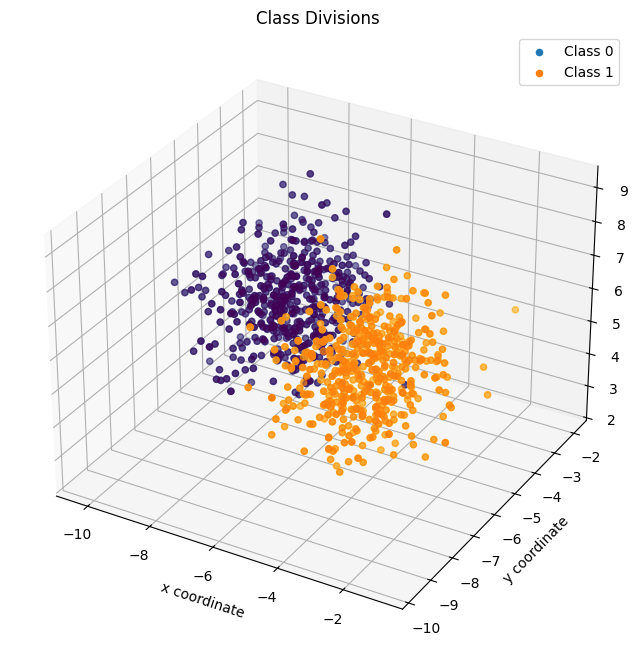

In [ ]:
coordinates, labels = make_blobs(n_samples=[500,500], 
                                 n_features=3, random_state=104)


print(coordinates)
print(labels)
# visualisera de nyss skapade blobsen

fig = plt.figure(figsize = (10, 8))
ax = plt.axes(projection ="3d")

ax.scatter3D(coordinates[:,0],
             coordinates[:,1],
             coordinates[:,2], 
             c=labels)

for label in set(labels):
    indices = labels == label
    ax.scatter3D(coordinates[indices, 0], coordinates[indices, 1], coordinates[indices, 2], label=f'Class {label}')

ax.legend()

ax.set_xlabel('x coordinate')
ax.set_ylabel('y coordinate')
ax.set_zlabel('z coordinate')

ax.set_title("Class Divisions");

To make this more explicit, let's make a df out of this data

In [10]:
df = pd.DataFrame(coordinates).rename(columns={0:'x', 1:'y', 2:'z'})
df['class'] = labels
df

,x,y,z,class
0,-7.800351,-7.042705,5.963284,0
1,-4.048452,-7.293812,5.132414,1
2,-2.485358,-7.547218,4.970742,1
3,-4.381966,-6.730893,5.092438,1
4,-3.511412,-6.218532,4.869813,1
...,...,...,...,...
995,-6.969128,-7.313662,8.038005,0
996,-6.873303,-7.277550,5.182108,0
997,-3.050327,-6.345468,6.989217,1
998,-5.713515,-5.746681,6.731784,0


In [11]:
df['class'].value_counts()

class
0    500
1    500
Name: count, dtype: int64

As seen above, we now have three features and one target. We want to train a model to be able to classify points in space to either class 0, or class 1.
  

**Train/test split**

In [13]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns=['class']).values, df['class'].values

test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=test_size, 
                                                    random_state=42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(800, 3)
(800,)
(200, 3)
(200,)


We need to reshape our targets. The features are already 2D, as required.

In [14]:
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

print(y_train.shape)
print(y_test.shape)

(800, 1)
(200, 1)


**Initialize a logistic regression classifier model** 

In [15]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()

#train the model
logistic_model.fit(X_train, y_train)

c:\Users\adiar\miniconda3\envs\programmering\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**Evaluate the model**

Now predict on both train and test set

In [16]:
# vi kan använda predict_proba för att få ut predicted sannolikhet för respektive klass

y_train_hats_probabilities = logistic_model.predict_proba(X_train)
y_test_hats_probabilities = logistic_model.predict_proba(X_test)

In [17]:
y_train_hats_probabilities[0]

array([7.80965775e-04, 9.99219034e-01])

In [18]:
y_test_hats_probabilities[0]

array([9.99942683e-01, 5.73166624e-05])

In [20]:
# vi kan använda predict för att direkt få ut den mest sannolika klassen

y_train_hats = logistic_model.predict(X_train)
y_test_hats = logistic_model.predict(X_test)

Have a look at our predictions on the test set

In [21]:
y_test_hats

array([0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0])

Accuracy is a pretty neat measure to use when performing binary classification

In [22]:
from sklearn.metrics import accuracy_score

print('Train accuracy:')
print(accuracy_score(y_train, y_train_hats))
print('Test accuracy:')
print(accuracy_score(y_test, y_test_hats))

Train accuracy:
0.9575
Test accuracy:
0.92


However, accuracy is **not** the end of the story here. Let's dive deeper into these results to try to do some *error analysis**.

A confusion matrix allows us to understand better how to interpret our results here.

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_hats)

cm

array([[89,  7],
       [ 9, 95]])

Ok, to understand the numbers above. Let's do a better plot.

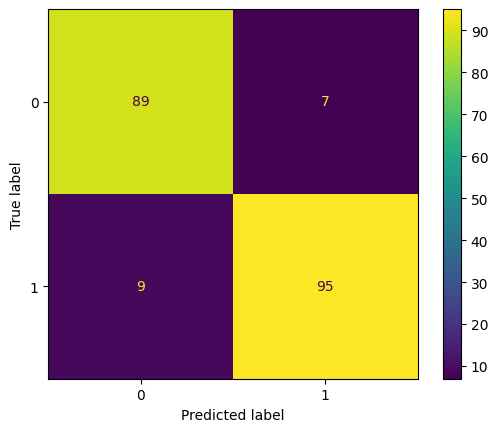

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true=y_test, y_pred=y_test_hats)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.show() 

---

## Challanges

**Task 1**

For the model trained above, run the code to predict the class for the following (new) data point.

Does the models prediction make sense? Try looking at the graph at the top and see if checks out.

In [ ]:
x = np.array([-2,-5,3])

x = x.reshape(1,3)        # note that the model now expects a single data point to have 1 row, and 3 columns (features)

In [ ]:
logistic_model.predict_proba(x)

**Task 2**

Try changing the coordinates of the new data point above, so that it predicts the opposite class of what it did in Task 1.

In [ ]:
x = np.array([-8,-5,3])

x = x.reshape(1,3)

logistic_model.predict_proba(x)

**Task 3**

Now try with a point that lies "in between" the classes, what does the model predict?

**Task 3**

Read more about how to interpret the confusion matrix [here](https://www.geeksforgeeks.org/confusion-matrix-machine-learning/).

**Important**: Make sure you understand the concepts precision, recall and accuracy.